# Lecture 00 — Course Introduction & the Scientific Python Toolkit

**Learning objectives**

By the end of this lecture you should be able to:

- Define machine learning and distinguish supervised, unsupervised and reinforcement learning.
- State the learning problem formally: data-generating distribution, hypothesis class, loss function, (true) risk and empirical risk.
- Explain why minimizing empirical risk is a proxy for minimizing true risk, and why that proxy can fail (overfitting).
- Use NumPy arrays, broadcasting and vectorization fluently, and measure the speed-up of vectorized code over Python loops.
- Load a bundled scikit-learn dataset into a pandas `DataFrame` and summarize it with `describe` and `groupby`.
- Produce basic exploratory plots with matplotlib and seaborn.
- Use the scikit-learn estimator API (`fit` / `predict` / `transform`, `train_test_split`) to train and evaluate a first model.

**Prerequisites**

- Basic Python programming (functions, lists, dictionaries, loops).
- Linear algebra, calculus and probability at an introductory level (reviewed in [`01_mathematical_foundations.ipynb`](01_mathematical_foundations.ipynb)).

**Contents**

1. What is machine learning?
2. The learning problem, formalized
3. Course roadmap
4. NumPy: arrays, broadcasting, vectorization
5. pandas: tabular data
6. Visualization with matplotlib and seaborn
7. The scikit-learn estimator API and a first model
8. Pitfalls & practical tips
9. Exercises
10. Summary and further reading

In [1]:
# Setup: imports and reproducibility
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)

np.random.seed(42)
rng = np.random.default_rng(42)

print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

numpy 2.4.6 | pandas 3.0.6 | scikit-learn 1.9.1


## 1. What is machine learning?

A classic definition due to Tom Mitchell (1997):

> A computer program is said to **learn** from experience $E$ with respect to some class of tasks $T$ and
> performance measure $P$ if its performance at tasks in $T$, as measured by $P$, improves with experience $E$.

Instead of writing the rules of a program by hand, we write a program that **infers rules from data**. The three
main paradigms differ in the kind of experience available:

| Paradigm | Experience $E$ | Goal | Examples |
|---|---|---|---|
| **Supervised learning** | Labelled pairs $(x_i, y_i)$ | Learn a map $f: \mathcal{X}\to\mathcal{Y}$ that predicts $y$ from $x$ | Regression (house prices), classification (spam, tumour malignancy) |
| **Unsupervised learning** | Unlabelled inputs $x_i$ | Discover structure in $p(x)$ | Clustering, dimensionality reduction, density estimation |
| **Reinforcement learning** | Interaction: states, actions, rewards | Learn a policy $\pi(a\mid s)$ maximizing expected cumulative reward | Games, robotics, recommendation |

Supervised learning splits further into **regression** ($\mathcal{Y}=\mathbb{R}$) and **classification**
($\mathcal{Y}$ a finite set). Hybrid settings exist too: semi-supervised learning (few labels, many unlabelled
points), self-supervised learning (labels manufactured from the data itself, as in modern language models), and
active learning (the learner chooses which points to label).

Most of this course is about supervised learning, because it has the cleanest theory and the most direct
applications; unsupervised methods and neural networks are covered later.

## 2. The learning problem, formalized

### 2.1 Ingredients

1. **Input space** $\mathcal{X}$ (e.g. $\mathbb{R}^d$) and **output space** $\mathcal{Y}$.
2. An unknown **data-generating distribution** $\mathcal{D}$ over $\mathcal{X}\times\mathcal{Y}$. We never see
   $\mathcal{D}$ itself, only a **training sample**
   $$S = \{(x_1,y_1),\dots,(x_n,y_n)\},\qquad (x_i,y_i)\overset{\text{i.i.d.}}{\sim}\mathcal{D}.$$
3. A **hypothesis class** $\mathcal{H}$ of candidate functions $h:\mathcal{X}\to\mathcal{Y}$ (e.g. all linear
   functions $h(x)=w^\top x + b$, all decision trees of depth $\le 5$, all neural networks with a given architecture).
4. A **loss function** $\ell:\mathcal{Y}\times\mathcal{Y}\to\mathbb{R}_{\ge 0}$ measuring the cost of predicting
   $\hat y$ when the truth is $y$. Common choices:
   - squared loss $\ell(\hat y, y) = (\hat y - y)^2$ (regression),
   - 0–1 loss $\ell(\hat y, y) = \mathbb{1}[\hat y \neq y]$ (classification),
   - logistic / cross-entropy loss (probabilistic classification).

### 2.2 Risk and empirical risk

The quantity we actually care about is the **(true, or population) risk** — the expected loss on a *fresh* draw
from $\mathcal{D}$:
$$R(h) = \mathbb{E}_{(x,y)\sim\mathcal{D}}\big[\ell(h(x), y)\big].$$
Since $\mathcal{D}$ is unknown, $R(h)$ cannot be computed. Instead we compute the **empirical risk** on the sample:
$$\hat R_S(h) = \frac{1}{n}\sum_{i=1}^n \ell(h(x_i), y_i).$$
For a *fixed* $h$ (chosen independently of $S$), $\hat R_S(h)$ is an unbiased estimator of $R(h)$:
$$\mathbb{E}_S\big[\hat R_S(h)\big] = \frac1n\sum_{i=1}^n \mathbb{E}\big[\ell(h(x_i),y_i)\big] = R(h),$$
and by the law of large numbers $\hat R_S(h)\to R(h)$ as $n\to\infty$.

**Empirical risk minimization (ERM)** picks
$$\hat h = \arg\min_{h\in\mathcal{H}} \hat R_S(h).$$

### 2.3 Why ERM can fail: generalization

The catch: $\hat h$ *depends on* $S$, so $\hat R_S(\hat h)$ is **no longer unbiased** — it is optimistically
biased. If $\mathcal{H}$ is very rich, ERM can drive the training error to zero by memorizing $S$ while $R(\hat h)$
stays large. This is **overfitting**. The gap $R(\hat h) - \hat R_S(\hat h)$ is the **generalization gap**.

It is useful to decompose the excess risk relative to the best possible predictor $f^\star$ (the *Bayes predictor*):
$$R(\hat h) - R(f^\star) = \underbrace{\big(R(\hat h) - \inf_{h\in\mathcal{H}} R(h)\big)}_{\text{estimation error}}
+ \underbrace{\big(\inf_{h\in\mathcal{H}} R(h) - R(f^\star)\big)}_{\text{approximation error}}.$$
Enlarging $\mathcal{H}$ decreases approximation error but increases estimation error — the
**bias–variance / complexity trade-off** that recurs throughout the course. Practical consequences:

- always evaluate on data **not used for training** (a held-out test set, or cross-validation);
- control model complexity (choice of $\mathcal{H}$, regularization, early stopping).

Below we make the gap concrete with a tiny simulation.

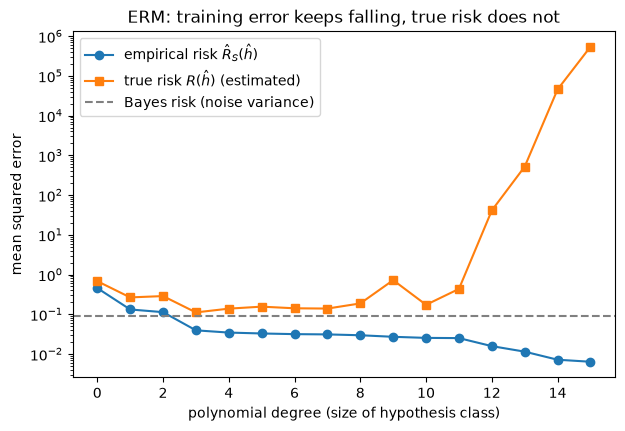

In [2]:
# Simulation: empirical vs true risk for polynomial fits of increasing degree.
# D: x ~ U(-1, 1), y = sin(3x) + noise(sd 0.3).  True risk approximated with a huge fresh sample.
def sample(n, rng):
    x = rng.uniform(-1, 1, n)
    y = np.sin(3 * x) + rng.normal(0, 0.3, n)
    return x, y

x_tr, y_tr = sample(20, rng)          # small training set S
x_big, y_big = sample(200_000, rng)   # proxy for the population D

degrees = range(0, 16)
emp_risk, true_risk = [], []
for d in degrees:
    coefs = np.polynomial.polynomial.polyfit(x_tr, y_tr, d)      # ERM with squared loss over degree-d polynomials
    pred = lambda x: np.polynomial.polynomial.polyval(x, coefs)
    emp_risk.append(np.mean((pred(x_tr) - y_tr) ** 2))
    true_risk.append(np.mean((pred(x_big) - y_big) ** 2))

plt.semilogy(list(degrees), emp_risk, "o-", label=r"empirical risk $\hat R_S(\hat h)$")
plt.semilogy(list(degrees), true_risk, "s-", label=r"true risk $R(\hat h)$ (estimated)")
plt.axhline(0.3 ** 2, color="gray", ls="--", label="Bayes risk (noise variance)")
plt.xlabel("polynomial degree (size of hypothesis class)")
plt.ylabel("mean squared error")
plt.title("ERM: training error keeps falling, true risk does not")
plt.legend(); plt.show()

Observations:

- The empirical risk decreases monotonically with the degree, because the hypothesis classes are nested.
- The true risk first decreases (less approximation error), then increases sharply (estimation error / overfitting).
- No model can beat the dashed line: the **Bayes risk** $R(f^\star)=\sigma^2=0.09$ is the irreducible noise.

This picture is the single most important idea of the course.

## 3. Course roadmap

| # | Notebook | Topic |
|---|---|---|
| 00 | [`00_course_introduction_and_python_toolkit.ipynb`](00_course_introduction_and_python_toolkit.ipynb) | The learning problem; NumPy, pandas, plotting, scikit-learn API |
| 01 | [`01_mathematical_foundations.ipynb`](01_mathematical_foundations.ipynb) | Linear algebra, calculus, probability, optimization |
| 02 | [`02_linear_regression.ipynb`](02_linear_regression.ipynb) | Least squares, gradient descent, bias–variance, Ridge / Lasso |
| 03+ | later notebooks | Classification (logistic regression, generative models), model evaluation and selection, SVMs and kernels, trees and ensembles, unsupervised learning (clustering, PCA), neural networks and deep learning |

Each lecture follows the same rhythm: **derive** the method, **implement it from scratch** in NumPy, **verify**
against scikit-learn (or PyTorch), and **visualize** its behaviour. The rest of this lecture gives you the tools to do so.

## 4. NumPy: arrays, broadcasting, vectorization

NumPy's `ndarray` is a contiguous, homogeneously typed, $n$-dimensional block of memory plus metadata
(`shape`, `dtype`, `strides`). Operations on whole arrays are executed in compiled C loops, which is why
"vectorized" NumPy code is orders of magnitude faster than equivalent Python loops.

### 4.1 Creating and inspecting arrays

In [3]:
a = np.array([1.0, 2.0, 3.0])               # 1-D array (a vector)
M = np.arange(12).reshape(3, 4)              # 2-D array (a 3x4 matrix)
Z = np.zeros((2, 3)); I = np.eye(3)
G = rng.normal(loc=0, scale=1, size=(2, 3))  # random Gaussian matrix

print("a:", a, "| shape", a.shape, "| dtype", a.dtype)
print("M =\n", M, "\nshape", M.shape, "ndim", M.ndim, "strides", M.strides)
print("linspace:", np.linspace(0, 1, 5))
print("G =\n", G.round(3))

a: [1. 2. 3.] | shape (3,) | dtype float64
M =
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]] 
shape (3, 4) ndim 2 strides (32, 8)
linspace: [0.   0.25 0.5  0.75 1.  ]
G =
 [[-0.273 -0.795  0.93 ]
 [ 0.04  -1.009 -1.511]]


### 4.2 Indexing, slicing and views

- Basic slicing (`M[1:, ::2]`) returns a **view**: no data is copied and modifying the view modifies the original.
- Boolean masks and integer arrays ("fancy indexing") return **copies**.
- Axis convention: for a data matrix $X\in\mathbb{R}^{n\times d}$, **rows are samples** and **columns are features**,
  so `X.mean(axis=0)` gives the per-feature mean.

In [4]:
print("row 1:", M[1], "| column 2:", M[:, 2], "| M[1:, ::2] =\n", M[1:, ::2])

v = M[0, :]          # a view
v[0] = 100
print("after modifying the view, M[0,0] =", M[0, 0])
M[0, 0] = 0          # restore

mask = M % 2 == 0
print("even entries (boolean mask, copy):", M[mask])
print("column means (axis=0):", M.mean(axis=0), "| row sums (axis=1):", M.sum(axis=1))

row 1: [4 5 6 7] | column 2: [ 2  6 10] | M[1:, ::2] =
 [[ 4  6]
 [ 8 10]]
after modifying the view, M[0,0] = 100
even entries (boolean mask, copy): [ 0  2  4  6  8 10]
column means (axis=0): [4. 5. 6. 7.] | row sums (axis=1): [ 6 22 38]


### 4.3 Broadcasting

Broadcasting lets NumPy combine arrays of different shapes without copying. Shapes are compared **from the
trailing dimension backwards**; two dimensions are compatible if they are equal or one of them is 1. Size-1
dimensions are (virtually) stretched.

Example: standardizing a data matrix $X\in\mathbb{R}^{n\times d}$,
$$\tilde X_{ij} = \frac{X_{ij}-\mu_j}{\sigma_j},$$
is written `(X - X.mean(0)) / X.std(0)`: shapes `(n, d)` and `(d,)` broadcast to `(n, d)`.

A second classic: the matrix of pairwise squared Euclidean distances between rows of $A\in\mathbb{R}^{m\times d}$
and $B\in\mathbb{R}^{k\times d}$, using $\|a-b\|^2 = \|a\|^2 + \|b\|^2 - 2a^\top b$:
$$D = \mathbf{a}\,\mathbf{1}^\top + \mathbf{1}\,\mathbf{b}^\top - 2AB^\top,\quad \mathbf{a}_i=\|A_{i\cdot}\|^2,\ \mathbf{b}_j = \|B_{j\cdot}\|^2.$$

In [5]:
X = rng.normal(loc=[5, -2, 10], scale=[1, 3, 0.5], size=(1000, 3))
X_std = (X - X.mean(axis=0)) / X.std(axis=0)          # (1000,3) op (3,) -> (1000,3)
print("means after standardizing:", X_std.mean(0).round(6), "| stds:", X_std.std(0).round(6))

# Outer operations via an explicit new axis: (3,1) + (1,4) -> (3,4)
col = np.array([[0], [10], [20]]); row = np.array([[1, 2, 3, 4]])
print("broadcast sum:\n", col + row)

# Pairwise squared distances, two ways
A = rng.normal(size=(5, 3)); B = rng.normal(size=(4, 3))
D_broadcast = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1)                 # (5,1,3)-(1,4,3) -> (5,4,3)
D_algebra = (A**2).sum(1)[:, None] + (B**2).sum(1)[None, :] - 2 * A @ B.T
print("max abs difference between the two formulas:", np.abs(D_broadcast - D_algebra).max())

means after standardizing: [-0.  0.  0.] | stds: [1. 1. 1.]
broadcast sum:
 [[ 1  2  3  4]
 [11 12 13 14]
 [21 22 23 24]]
max abs difference between the two formulas: 3.552713678800501e-15


### 4.4 Vectorization vs Python loops

Let us time three implementations of the same computation — the dot product and the pairwise distance
matrix — to see why ML code is written in vectorized form.

In [6]:
def timeit(f, repeat=3):
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter(); f(); best = min(best, time.perf_counter() - t0)
    return best

n = 200_000
x = rng.normal(size=n); y = rng.normal(size=n)

def dot_loop():
    s = 0.0
    for i in range(n):
        s += x[i] * y[i]
    return s

t_loop = timeit(dot_loop, repeat=1)
t_vec = timeit(lambda: x @ y)
print(f"dot product, n={n:,}:  loop {t_loop*1e3:8.2f} ms | vectorized {t_vec*1e3:6.3f} ms | speed-up ~{t_loop/t_vec:,.0f}x")
print("same result:", np.isclose(dot_loop(), x @ y))

# Pairwise distances for m=k=150 points in d=10
P = rng.normal(size=(150, 10))
def dist_loop():
    m = len(P); out = np.empty((m, m))
    for i in range(m):
        for j in range(m):
            out[i, j] = sum((P[i, k] - P[j, k]) ** 2 for k in range(P.shape[1]))
    return out
def dist_vec():
    sq = (P**2).sum(1)
    return sq[:, None] + sq[None, :] - 2 * P @ P.T

t_loop2, t_vec2 = timeit(dist_loop, repeat=1), timeit(dist_vec)
print(f"pairwise distances 150x150: loop {t_loop2*1e3:8.1f} ms | vectorized {t_vec2*1e3:6.3f} ms | speed-up ~{t_loop2/t_vec2:,.0f}x")
print("max abs diff:", np.abs(dist_loop() - dist_vec()).max().round(10))

dot product, n=200,000:  loop    44.60 ms | vectorized 15.997 ms | speed-up ~3x


same result: True


pairwise distances 150x150: loop    174.7 ms | vectorized  0.068 ms | speed-up ~2,588x


max abs diff: 0.0


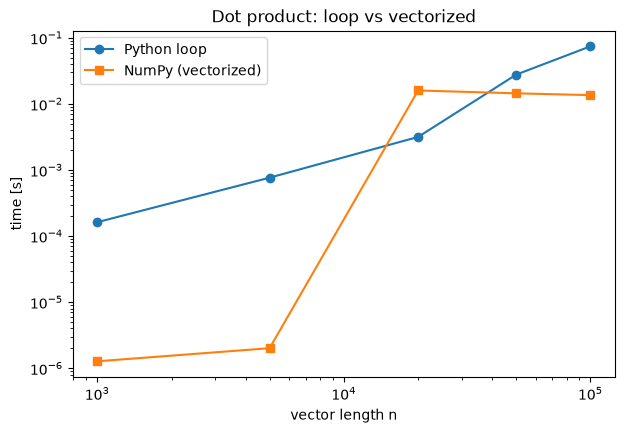

In [7]:
# How does run time scale with n?  (both are O(n) but with very different constants)
sizes = [1_000, 5_000, 20_000, 50_000, 100_000]
t_l, t_v = [], []
for m in sizes:
    xs, ys = rng.normal(size=m), rng.normal(size=m)
    t_l.append(timeit(lambda: sum(a * b for a, b in zip(xs, ys)), repeat=1))
    t_v.append(timeit(lambda: xs @ ys))
plt.loglog(sizes, t_l, "o-", label="Python loop")
plt.loglog(sizes, t_v, "s-", label="NumPy (vectorized)")
plt.xlabel("vector length n"); plt.ylabel("time [s]"); plt.title("Dot product: loop vs vectorized")
plt.legend(); plt.show()

### 4.5 Linear algebra essentials

`@` is matrix multiplication; `np.linalg` provides `solve`, `inv`, `eig`, `svd`, `norm`, `lstsq`, ...
**Never form an explicit inverse to solve a linear system** — `np.linalg.solve` is faster and numerically more stable.

In [8]:
A = rng.normal(size=(4, 4)); A = A @ A.T + 4 * np.eye(4)      # symmetric positive definite
b = rng.normal(size=4)
x_solve = np.linalg.solve(A, b)
x_inv = np.linalg.inv(A) @ b
print("solution:", x_solve.round(4))
print("residual ||Ax-b||:", np.linalg.norm(A @ x_solve - b), "| solve vs inv diff:", np.abs(x_solve - x_inv).max())
print("condition number of A:", np.linalg.cond(A).round(2))

solution: [ 0.016  -0.0378 -0.0245  0.1282]
residual ||Ax-b||: 1.2442938235622048e-16 | solve vs inv diff: 0.0
condition number of A: 2.92


## 5. pandas: tabular data

A `DataFrame` is a table with labelled columns (each a typed `Series`) and a row index. It is the standard
container for exploratory data analysis. We load the **Wine** dataset bundled with scikit-learn: 178 wines
from three cultivars, described by 13 chemical measurements.

In [9]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame.copy()                                        # features + 'target' column
df["cultivar"] = df["target"].map(dict(enumerate(wine.target_names)))
print(df.shape)
df.head()

(178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [10]:
df.info(verbose=False)
print("\nmissing values:", int(df.isna().sum().sum()))
df[["alcohol", "malic_acid", "color_intensity", "proline"]].describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Columns: 15 entries, alcohol to cultivar
dtypes: float64(13), int64(1), str(1)
memory usage: 21.0 KB

missing values: 0


,alcohol,malic_acid,color_intensity,proline
count,178.00,178.00,178.00,178.00
mean,13.00,2.34,5.06,746.89
std,0.81,1.12,2.32,314.91
min,11.03,0.74,1.28,278.00
25%,12.36,1.60,3.22,500.50
50%,13.05,1.87,4.69,673.50
75%,13.68,3.08,6.20,985.00
max,14.83,5.80,13.00,1680.00


`describe()` gives count, mean, standard deviation, min, quartiles and max per column. Note the very different
**scales** of the features (e.g. `proline` is in the hundreds, `hue` around 1) — algorithms based on distances or
gradient descent will need feature scaling (Lecture 02).

**Split–apply–combine** with `groupby`: split rows by a key, apply an aggregation to each group, combine the results.

In [11]:
summary = (df.groupby("cultivar")[["alcohol", "flavanoids", "color_intensity", "proline"]]
             .agg(["mean", "std"]).round(2))
summary

alcohol       flavanoids       color_intensity        proline        
            mean   std       mean   std            mean   std     mean     std
cultivar                                                                      
class_0    13.74  0.46       2.98  0.40            5.53  1.24  1115.71  221.52
class_1    12.28  0.54       2.08  0.71            3.09  0.92   519.51  157.21
class_2    13.15  0.53       0.78  0.29            7.40  2.31   629.90  115.10

In [12]:
# Other everyday operations: filtering, new columns, sorting, value counts
print(df["cultivar"].value_counts(), "\n")
strong = df.query("alcohol > 14")
print(f"{len(strong)} wines with alcohol > 14%, by cultivar:", {str(k): int(v) for k, v in strong["cultivar"].value_counts().items()})
df["phenol_ratio"] = df["flavanoids"] / df["total_phenols"]
df.sort_values("phenol_ratio", ascending=False)[["cultivar", "flavanoids", "total_phenols", "phenol_ratio"]].head(3)

cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64 

22 wines with alcohol > 14%, by cultivar: {'class_0': 19, 'class_2': 3}


,cultivar,flavanoids,total_phenols,phenol_ratio
121,class_1,5.08,3.18,1.597484
107,class_1,1.76,1.38,1.275362
106,class_1,2.03,1.65,1.230303


## 6. Visualization with matplotlib and seaborn

matplotlib has two interfaces: the stateful `plt.*` interface (convenient for quick plots) and the
**object-oriented** interface (`fig, ax = plt.subplots(...)`, then `ax.plot(...)`), which is preferable for anything
with more than one panel. seaborn builds on matplotlib and works directly with `DataFrame`s, producing statistical
plots (histograms with KDEs, box plots, pair plots, heatmaps) with little code.

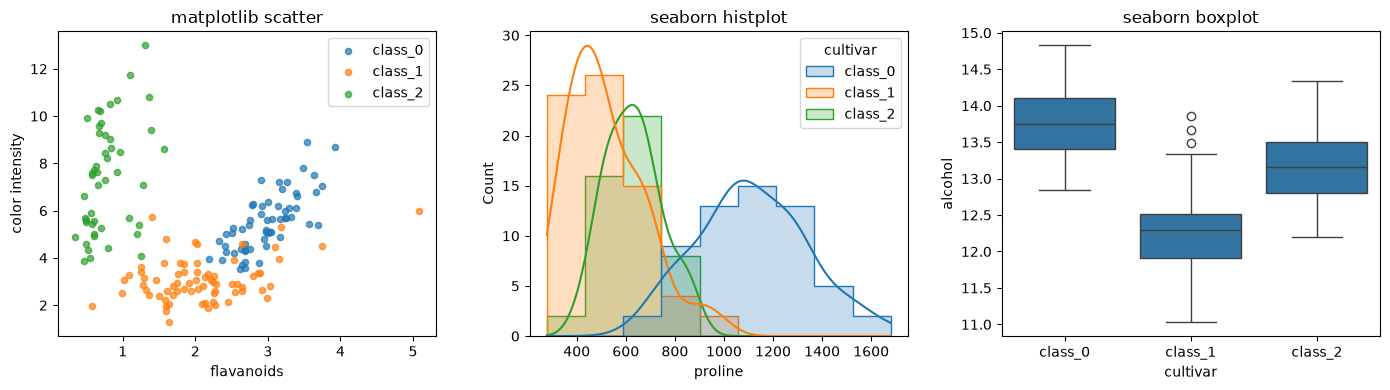

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (1) plain matplotlib: scatter coloured by class
for name, g in df.groupby("cultivar"):
    axes[0].scatter(g["flavanoids"], g["color_intensity"], label=name, alpha=0.7, s=20)
axes[0].set(xlabel="flavanoids", ylabel="color intensity", title="matplotlib scatter")
axes[0].legend()

# (2) seaborn histogram + kernel density estimate
sns.histplot(data=df, x="proline", hue="cultivar", kde=True, ax=axes[1], element="step")
axes[1].set_title("seaborn histplot")

# (3) seaborn box plot
sns.boxplot(data=df, x="cultivar", y="alcohol", ax=axes[2])
axes[2].set_title("seaborn boxplot")
plt.tight_layout(); plt.show()

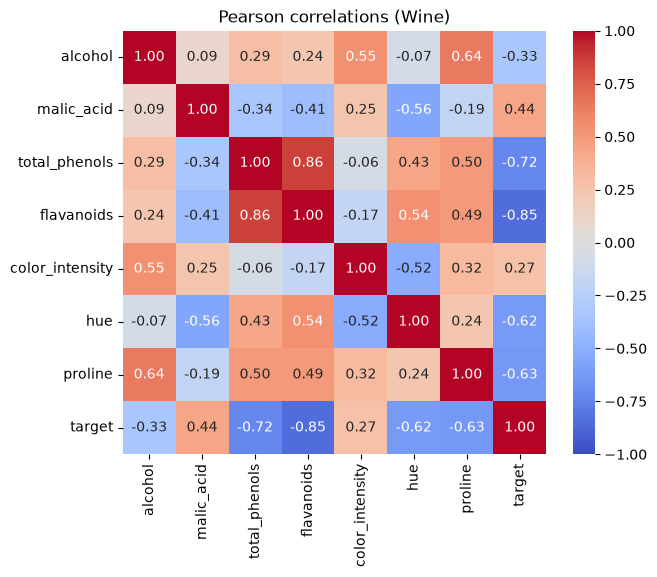

In [14]:
# Correlation heatmap of a subset of features
cols = ["alcohol", "malic_acid", "total_phenols", "flavanoids", "color_intensity", "hue", "proline", "target"]
corr = df[cols].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Pearson correlations (Wine)"); plt.show()

The heatmap already suggests that `flavanoids`, `total_phenols` and `hue` are strongly (negatively) associated
with the class label, and that `flavanoids` and `total_phenols` are highly collinear — information that matters
when interpreting linear models.

## 7. The scikit-learn estimator API and a first model

scikit-learn exposes every algorithm through one consistent interface:

| Method | Available on | Meaning |
|---|---|---|
| `est.fit(X, y)` | all estimators | learn parameters from data; returns `self` |
| `est.predict(X)` | predictors (classifiers, regressors) | output $\hat y$ |
| `est.predict_proba(X)` | probabilistic classifiers | output $\hat p(y\mid x)$ |
| `est.transform(X)` | transformers (scalers, PCA, ...) | map $X\mapsto X'$ |
| `est.fit_transform(X)` | transformers | `fit` then `transform` (sometimes more efficient) |
| `est.score(X, y)` | predictors | default metric (accuracy / $R^2$) |

Conventions: `X` has shape `(n_samples, n_features)`; `y` has shape `(n_samples,)`; hyperparameters are
passed to the constructor; learned attributes end with an underscore (`coef_`, `mean_`, ...).

### 7.1 Train/test split

To estimate the true risk $R(\hat h)$ honestly we hold out a test set that is **never** used during training.
`train_test_split` shuffles and splits; `stratify=y` preserves class proportions.

In [15]:
from sklearn.model_selection import train_test_split

X = wine.data.values; y = wine.target.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("train:", X_train.shape, "test:", X_test.shape)
print("class proportions train:", np.bincount(y_train) / len(y_train))
print("class proportions test: ", np.bincount(y_test) / len(y_test))

train: (124, 13) test: (54, 13)
class proportions train: [0.33064516 0.40322581 0.26612903]
class proportions test:  [0.33333333 0.38888889 0.27777778]


### 7.2 A transformer: `StandardScaler`

The scaler *learns* per-feature means $\mu_j$ and standard deviations $\sigma_j$ **from the training set only** and
then applies $x_j \mapsto (x_j-\mu_j)/\sigma_j$ to any data. Fitting it on the full dataset would leak test-set
information into training.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)               # uses TRAIN statistics
print("learned means (first 3):", scaler.mean_[:3].round(2))
print("train means after scaling ~0:", X_train_s.mean(0)[:3].round(6))
print("test means after scaling (not exactly 0):", X_test_s.mean(0)[:3].round(3))
# Equivalent from-scratch computation
manual = (X_test - X_train.mean(0)) / X_train.std(0)
print("matches manual broadcasting:", np.allclose(manual, X_test_s))

learned means (first 3): [12.96  2.29  2.36]
train means after scaling ~0: [0. 0. 0.]
test means after scaling (not exactly 0): [0.182 0.154 0.037]
matches manual broadcasting: True


### 7.3 A first predictor: $k$-nearest neighbours

The $k$-NN classifier predicts the majority label among the $k$ training points closest to $x$:
$$\hat y(x) = \arg\max_{c}\ \sum_{i\in N_k(x)} \mathbb{1}[y_i=c].$$
It has no training phase beyond storing the data, which makes it a perfect first example. We implement it from
scratch with the broadcasting distance trick of Section 4.3 and compare to scikit-learn.

In [17]:
def knn_predict(X_train, y_train, X_query, k=5):
    # squared Euclidean distances, shape (n_query, n_train)
    d2 = (X_query**2).sum(1)[:, None] + (X_train**2).sum(1)[None, :] - 2 * X_query @ X_train.T
    nn_idx = np.argsort(d2, axis=1)[:, :k]                  # indices of the k nearest neighbours
    nn_labels = y_train[nn_idx]                             # (n_query, k)
    # majority vote per row (ties broken toward the smallest label, as argmax does)
    counts = np.apply_along_axis(np.bincount, 1, nn_labels, minlength=y_train.max() + 1)
    return counts.argmax(axis=1)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

y_hat_scratch = knn_predict(X_train_s, y_train, X_test_s, k=5)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
y_hat_sk = knn.predict(X_test_s)

print(f"from-scratch accuracy: {accuracy_score(y_test, y_hat_scratch):.4f}")
print(f"scikit-learn accuracy: {accuracy_score(y_test, y_hat_sk):.4f}")
print("predictions agree on", (y_hat_scratch == y_hat_sk).mean() * 100, "% of test points")

from-scratch accuracy: 0.9444
scikit-learn accuracy: 0.9444
predictions agree on 100.0 % of test points


### 7.4 Why scaling mattered, and `Pipeline`

$k$-NN relies on distances, so an unscaled feature such as `proline` (values ~1000) dominates everything else.
A `Pipeline` chains transformers and a final estimator into a single estimator, guaranteeing the scaler is fit only on
the training data (also inside cross-validation, Lecture on model selection).

In [18]:
from sklearn.pipeline import make_pipeline

raw = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(X_train, y_train)
print(f"k-NN without scaling: test accuracy = {raw.score(X_test, y_test):.3f}")
print(f"k-NN with scaling   : test accuracy = {pipe.score(X_test, y_test):.3f}")
print(pipe)

k-NN without scaling: test accuracy = 0.722
k-NN with scaling   : test accuracy = 0.944
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier())])


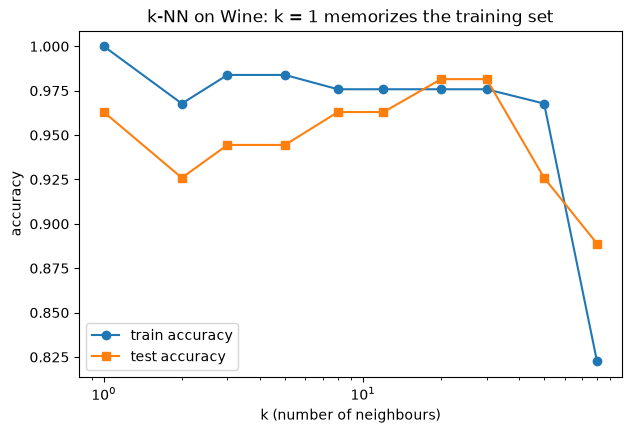

In [19]:
# Train vs test accuracy as a function of k: the complexity trade-off again (small k = complex model)
ks = [1, 2, 3, 5, 8, 12, 20, 30, 50, 80]
tr_acc, te_acc = [], []
for k in ks:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X_train, y_train)
    tr_acc.append(m.score(X_train, y_train)); te_acc.append(m.score(X_test, y_test))
plt.plot(ks, tr_acc, "o-", label="train accuracy")
plt.plot(ks, te_acc, "s-", label="test accuracy")
plt.xscale("log"); plt.xlabel("k (number of neighbours)"); plt.ylabel("accuracy")
plt.title("k-NN on Wine: k = 1 memorizes the training set"); plt.legend(); plt.show()

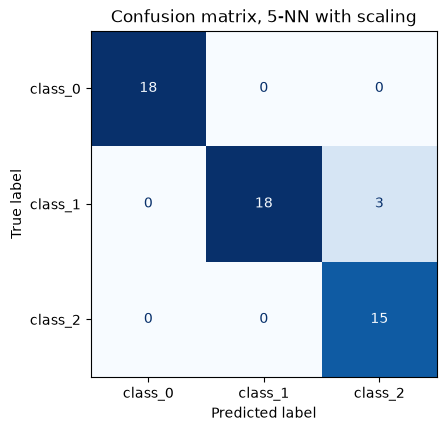

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(y_test, pipe.predict(X_test)),
                       display_labels=wine.target_names).plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix, 5-NN with scaling"); plt.show()

With a handful of lines we have gone from raw data to a validated classifier. Everything in the rest of the course
refines one of the steps: better hypothesis classes, better losses and optimizers, and more reliable evaluation.

## 8. Pitfalls & practical tips

- **Evaluate on held-out data.** Training accuracy is an optimistically biased estimate of true performance.
  The test set is used *once*, at the very end; use a validation set or cross-validation for model choices.
- **Data leakage.** Any statistic computed from the data (scaling parameters, imputation values, selected features)
  must be learned on the training split only. Pipelines make this automatic.
- **Shapes.** `X` must be 2-D `(n_samples, n_features)` even for a single feature (`x.reshape(-1, 1)`).
  A 1-D array of shape `(n,)` and a column `(n, 1)` broadcast very differently: `(n,) - (n,1)` yields an `(n, n)` matrix!
- **Views vs copies.** Slices are views; use `.copy()` when you intend to modify a sub-array independently.
  In pandas, prefer `.loc[row, col] = value` to chained indexing.
- **Vectorize.** Replace explicit Python loops over samples with array operations; loops over a small number of
  epochs or hyperparameter values are fine.
- **Reproducibility.** Seed your random generators (`np.random.default_rng(seed)`, `random_state=`) and record
  library versions.
- **Stratify** classification splits, especially with imbalanced classes.

## 9. Exercises

**Exercise 1 (pen and paper — risk).** Let $x\sim\mathcal{U}[0,1]$ and $y = 2x + \varepsilon$ with
$\varepsilon\sim\mathcal{N}(0,\sigma^2)$ independent of $x$. For the constant hypothesis class
$\mathcal{H}=\{h_c(x)=c\}$ and squared loss, (a) compute the true risk $R(h_c)$ as a function of $c$;
(b) find the risk minimizer $c^\star$ in $\mathcal{H}$; (c) compute the Bayes risk $R(f^\star)$ and the approximation
error $R(h_{c^\star}) - R(f^\star)$.

**Exercise 2 (pen and paper — ERM bias).** Show that for a *fixed* hypothesis $h$,
$\mathrm{Var}[\hat R_S(h)] = \mathrm{Var}[\ell(h(x),y)]/n$. Then explain in two or three sentences why
$\mathbb{E}_S[\hat R_S(\hat h)] \le \inf_{h\in\mathcal{H}} R(h)$ for the ERM solution $\hat h$ (hint: compare
$\hat R_S(\hat h)$ with $\hat R_S(h)$ for any fixed $h$).

**Exercise 3 (coding — broadcasting).** Write a function `standardize_columns(X)` that returns the column-standardized
matrix *without* any Python loop, and a function `cosine_similarity_matrix(A, B)` returning the matrix
$S_{ij} = \frac{a_i^\top b_j}{\|a_i\|\,\|b_j\|}$. Check the latter against `sklearn.metrics.pairwise.cosine_similarity`.

**Exercise 4 (coding — pandas).** Using the Wine `DataFrame`, (a) compute for each cultivar the median of every
feature, (b) find the three features whose per-cultivar means differ most *relative to their overall standard deviation*,
and (c) plot these three features in a seaborn `pairplot` coloured by cultivar.

**Exercise 5 (coding — estimator API).** Implement a minimal scikit-learn-compatible classifier `NearestCentroid`
with `fit(X, y)` (stores the class means in `centroids_`) and `predict(X)` (assigns the closest centroid).
Evaluate it with and without a `StandardScaler` in a pipeline on the Wine split above and compare with 5-NN.

In [21]:
# Exercise 3 — starter code
def standardize_columns(X):
    # TODO: return (X - column means) / column standard deviations, fully vectorized
    return None

def cosine_similarity_matrix(A, B):
    # TODO: return the (len(A), len(B)) matrix of cosine similarities
    return None

# from sklearn.metrics.pairwise import cosine_similarity
# A_, B_ = rng.normal(size=(5, 3)), rng.normal(size=(4, 3))
# print(np.allclose(cosine_similarity_matrix(A_, B_), cosine_similarity(A_, B_)))

In [22]:
# Exercise 4 — starter code
# TODO (a): per-cultivar medians
medians = None      # e.g. df.groupby("cultivar")[wine.feature_names].median()
# TODO (b): rank features by (max group mean - min group mean) / overall std
top3 = None
# TODO (c): sns.pairplot(df, vars=top3, hue="cultivar")

In [23]:
# Exercise 5 — starter code
from sklearn.base import BaseEstimator, ClassifierMixin

class NearestCentroid(ClassifierMixin, BaseEstimator):
    def fit(self, X, y):
        # TODO: store self.classes_ and self.centroids_ (shape (n_classes, n_features))
        return self

    def predict(self, X):
        # TODO: compute distances to each centroid (broadcasting!) and return the closest class
        pass

# model = make_pipeline(StandardScaler(), NearestCentroid()).fit(X_train, y_train)
# print(model.score(X_test, y_test))

## 10. Summary

- Machine learning infers a predictor from data. Supervised learning uses labelled pairs, unsupervised learning
  finds structure in unlabelled inputs, reinforcement learning learns from rewards through interaction.
- Formally: data $\sim\mathcal{D}$, a hypothesis class $\mathcal{H}$, a loss $\ell$. We want small **true risk** $R(h)$
  but can only compute the **empirical risk** $\hat R_S(h)$; ERM minimizes the latter.
- The ERM solution's training error is optimistically biased. Richer hypothesis classes reduce approximation error
  but increase estimation error, so we must **evaluate on held-out data** and **control complexity**.
- NumPy: broadcasting plus vectorization gives concise code that runs 100–1000x faster than Python loops.
- pandas: `DataFrame`s, `describe`, `groupby`/`agg`, `query` for exploratory analysis; matplotlib/seaborn for plots.
- scikit-learn: a uniform `fit`/`predict`/`transform` API, `train_test_split`, and `Pipeline` to avoid leakage.

## Further reading

- James, Witten, Hastie, Tibshirani, Taylor — *An Introduction to Statistical Learning (ISLP)*, Ch. 1–2.
- Hastie, Tibshirani, Friedman — *The Elements of Statistical Learning (ESL)*, Ch. 1–2.
- Shalev-Shwartz, Ben-David — *Understanding Machine Learning*, Ch. 2–3 (ERM, PAC learning).
- Murphy — *Probabilistic Machine Learning: An Introduction (PML)*, Ch. 1.
- Bishop — *Pattern Recognition and Machine Learning (PRML)*, Ch. 1.
- Géron — *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*, Ch. 1–2.
- VanderPlas — *Python Data Science Handbook*, Ch. 2–4 (NumPy, pandas, matplotlib).
- Harris et al. (2020), "Array programming with NumPy", *Nature* 585.
- Pedregosa et al. (2011), "Scikit-learn: Machine Learning in Python", *JMLR* 12; Buitinck et al. (2013), "API design for machine learning software: experiences from the scikit-learn project".
- Mitchell — *Machine Learning* (1997), Ch. 1.